# Hands-On Practice: Bony Anatomy Segmentation


## Package Setup

In [ ]:
!pip install segmentation-models-pytorch albumentations torchmetrics pydicom nibabel grad_cam
!wget https://github.com/pitthexai/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/raw/refs/heads/main/Sample_Dataset/knee_sample.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 18.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 113.0 MB/s eta 0:00:00
  Created wheel for grad_cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=7fb578c363999948a7fd467ab28a2bfe3f9e2b62e01705ec637394819dc4afc3
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad_cam
--2026-06-11 14:53:38--  https://github.com/pitthexai/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/raw/refs/heads/main/Sample_Dataset/knee_sample.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import copy

from zipfile import ZipFile

from io import BytesIO
from gzip import GzipFile

import os

import cv2
from PIL import Image

import pydicom
import nibabel
from nibabel import FileHolder, Nifti1Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from segmentation_models_pytorch import utils as smp_utils

from torchmetrics.segmentation import DiceScore, MeanIoU
import torchvision.transforms.functional as TF

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
RANDOM_STATE = 42

## Step 1: Data Preprocessing

In [ ]:
# Directories for

filename = "knee_seg_sample.csv"
directory = "KneeSample"
zipfile = "knee_sample.zip"

classes = {
    0: "Background",
    1: "R Patella",
    2: "R Femur",
    3: "R Tibia",
    4: "R Fibula",
    5: "L Patella",
    6: "L Femur",
    7: "L Tibia",
    8: "L Fibula"
}

zipfile_loc = f"/content/{zipfile}"
csv_data_location = f"/content/data/{directory}/{filename}"
data_save_location = f"/content/data/{directory}/"

In [ ]:
if not os.path.exists(data_save_location):
    with ZipFile(zipfile_loc, 'r') as zipf:
        zipf.extractall("/content/")

In [ ]:
data_records = pd.read_csv(csv_data_location)

train, test = train_test_split(data_records.id.unique(), test_size=0.3, random_state=42)
valid, test = train_test_split(test, test_size=0.5, random_state=42)

train = data_records[data_records.id.isin(train)].reset_index(drop=True)
valid = data_records[data_records.id.isin(valid)].reset_index(drop=True)
test = data_records[data_records.id.isin(test)].reset_index(drop=True)

In [ ]:
test

,id,V00AGE,P02SEX,P02RACE
0,9634146,53,1: Male,1: White or Caucasian
1,9772637,67,1: Male,2: Black or African American
2,9301222,51,2: Female,1: White or Caucasian
3,9068894,64,2: Female,2: Black or African American
4,9016304,71,2: Female,1: White or Caucasian
5,9289212,60,2: Female,2: Black or African American
6,9004184,68,1: Male,2: Black or African American
7,9217512,69,2: Female,2: Black or African American
8,9573142,78,2: Female,1: White or Caucasian
9,9125488,49,2: Female,1: White or Caucasian


## Step 2: Modeling
In this section, we develop and train a segmentation model


In [ ]:
class BonyAnatomyJointSegmentationDataset(Dataset):
    def __init__(self, root_dir, ids, num_classes, transforms=None, preprocessing=None):
        self.root_dir = root_dir
        self.pids = ids
        self.num_classes = num_classes
        self.transforms = transforms
        self.preprocessing = preprocessing

    def load_dicom(self, path):
        dicom_img = pydicom.dcmread(path)
        return dicom_img.pixel_array.astype(np.float32)

    def load_nii(self, path):
        nii_annot = nibabel.load(path)
        nii_annot_data = nii_annot.get_fdata()

        if len(nii_annot_data.shape) == 3 and nii_annot_data.shape[-1] > 1:
            if nii_annot_data.shape[-1] == 2:
                nii_annot_data = nii_annot_data[:, :, 1]
            else:
                nii_annot_data = nii_annot_data[:, :, nii_annot_data.shape[-1]//2]

            nii_annot_data = np.expand_dims(nii_annot_data, axis=-1)


        nii_annot_data = cv2.rotate(nii_annot_data, cv2.ROTATE_90_CLOCKWISE)
        nii_annot_data = cv2.flip(nii_annot_data, 1)
        return nii_annot_data

    def get_file_path(self, filename):
        return os.path.join(self.root_dir, filename)

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):

        image = self.load_dicom(self.get_file_path(os.path.join("Images/", str(self.pids[idx]) + ".dcm")))
        mask = self.load_nii(self.get_file_path(os.path.join("Annotations", str(self.pids[idx]) + ".nii.gz")))

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        if self.preprocessing is not None:
            transformed = self.preprocessing(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image.type(torch.FloatTensor), mask.long()


In [ ]:
def train_model(train_loader, valid_loader, lr=5e-04, encoder="resnet18", encoder_weights="imagenet",
                activation=None, epochs=50, num_classes=9):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = copy.deepcopy(smp.Unet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=1,
                    classes=num_classes, activation=activation)).to(device)
    model.encoder.requires_grad_ = False
    model.decoder.requires_grad_ = False

    loss = nn.CrossEntropyLoss()
    loss.__name__="loss"

    multi_jaccard = MeanIoU(num_classes=num_classes, per_class=False).to(device)
    multi_jaccard.__name__ = "iou_score"
    metrics = [multi_jaccard]

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # create epoch runners
    # it is a simple loop of iterating over dataloader`s samples
    train_epoch = smp.utils.train.TrainEpoch(
        model,
        loss=loss,
        metrics=[],
        optimizer=optimizer,
        device=device,
        verbose=True,
    )

    valid_epoch = smp.utils.train.ValidEpoch(
        model,
        loss=loss,
        metrics=[],
        device=device,
        verbose=True,
    )

    max_score = np.inf

    for i in range(1, epochs+1):

        print('\nEpoch: {}'.format(i))
        train_logs = train_epoch.run(train_loader)
        valid_logs = valid_epoch.run(valid_loader)

        # do something (save model, change lr, etc.)
        print(valid_logs)
        if valid_logs['loss'] < max_score:
            print("Updated Max Score:", max_score)
            max_score = valid_logs['loss']
            torch.save(model, './best_model.pth')
            print('Model saved!')

    # Return best model
    model = torch.load('./best_model.pth', weights_only=False)
    return model

In [ ]:
def test_model(model, test_loader, class_labels):
    model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(10, 10), sharex=True, sharey=True)

    x, y = next(iter(test_loader))
    out = torch.softmax(model(x.to(device)), dim=1)
    #out = out.detach().cpu().numpy()

    for i, pred in enumerate(out):
        uni_channels = torch.argmax(pred, dim=0).unique()
        pred = pred.detach().cpu().numpy()
        ax[i][0].imshow(x[i].squeeze(), cmap="gray")
        yi = y[i].squeeze()
        ax[i][1].imshow(yi)

        # Merge predicted masks into one image
        mask = np.where(pred[uni_channels[0].item(),:,:] > 0.5, uni_channels[0].item(), 0)
        for channel in uni_channels[1:]:
            channel = channel.item()
            channel_mask = np.where(pred[channel,:,:] > 0.5, channel, 0)
            mask = mask | channel_mask
        ax[i][2].imshow(mask)

    ax[0][0].set_title("Image")
    ax[0][1].set_title("Ground Truth Mask")
    ax[0][2].set_title("Predicted Mask")
    plt.xticks([])
    plt.yticks([])

    plt.show()

    multi_jaccard = MeanIoU(num_classes=num_classes, per_class=True, input_format="index").cuda()
    multi_jaccard.__name__ = "iou"
    metrics = [multi_jaccard]

    results = torch.zeros((1, num_classes))
    for x, y in test_loader:
        preds = model(x.cuda())
        pred_idx = preds.argmax(dim=1)  # [B, H, W]
        results += multi_jaccard(pred_idx, y.cuda()).detach().cpu()

    results = results/len(test_loader)

    for i in range(0, len(class_labels)):
        print(f"{class_labels[i]} (Class {i}): {results[0][i]}")

    return results

In [ ]:
augmentations = A.Compose([A.Resize(256, 256), ToTensorV2()])

num_classes = 9

In [ ]:
train_set = BonyAnatomyJointSegmentationDataset(data_save_location, train.id, num_classes,
                                                transforms=augmentations)

valid_set = BonyAnatomyJointSegmentationDataset(data_save_location, valid.id, num_classes,
                                                transforms=augmentations)

test_set = BonyAnatomyJointSegmentationDataset(data_save_location, test.id, num_classes,
                                               transforms=augmentations)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_set, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=5, shuffle=False, num_workers=2)

## Encoder Backbone: ResNet18

In [ ]:
model = train_model(train_loader, valid_loader, num_classes=num_classes, encoder="resnet18", epochs=50)


Epoch: 1
train:  40%|████      | 2/5 [00:04<00:05,  1.84s/it, loss - 2.574]

/usr/local/lib/python3.12/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


valid: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it, loss - 2.053]
{'loss': np.float32(2.0527482)}
Updated Max Score: inf
Model saved!

Epoch: 2
train:  40%|████      | 2/5 [00:04<00:06,  2.08s/it, loss - 2.065]

/usr/local/lib/python3.12/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


valid: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it, loss - 2.073]
{'loss': np.float32(2.0731046)}

Epoch: 3
train:   0%|          | 0/5 [00:00<?, ?it/s]

...

valid: 100%|██████████| 1/1 [00:02<00:00,  2.16s/it, loss - 0.07647]
{'loss': np.float32(0.076465555)}
Updated Max Score: 0.078455366
Model saved!

Epoch: 49
train:  80%|████████  | 4/5 [00:09<00:01,  1.88s/it, loss - 0.05069]

/usr/local/lib/python3.12/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


valid: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it, loss - 0.07618]
{'loss': np.float32(0.07617988)}
Updated Max Score: 0.076465555
Model saved!

Epoch: 50
train:  40%|████      | 2/5 [00:04<00:06,  2.16s/it, loss - 0.04853]

/usr/local/lib/python3.12/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


valid: 100%|██████████| 1/1 [00:02<00:00,  2.18s/it, loss - 0.07374]
{'loss': np.float32(0.07374465)}
Updated Max Score: 0.07617988
Model saved!


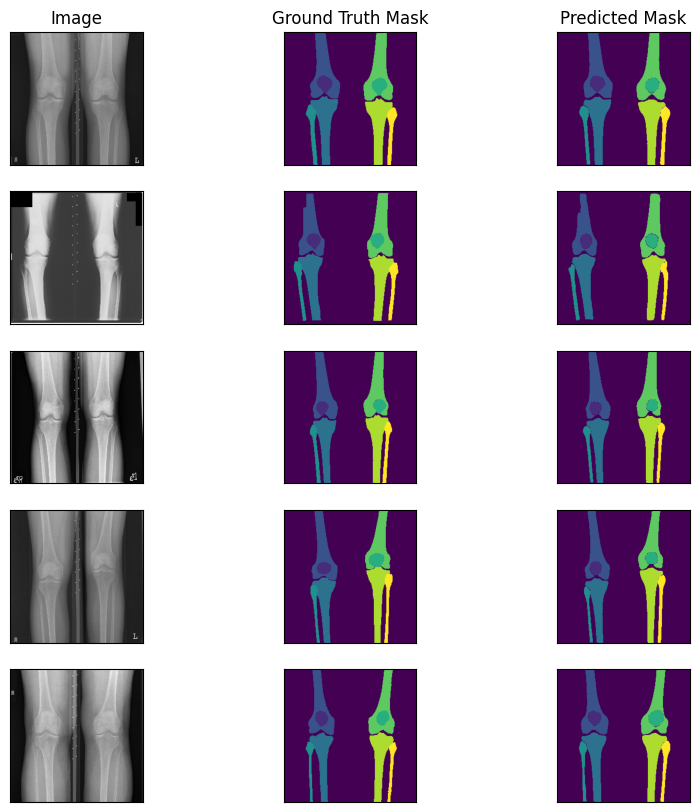

Background (Class 0): 0.980272114276886
R Patella (Class 1): 0.8113899230957031
R Femur (Class 2): 0.9001829624176025
R Tibia (Class 3): 0.9433855414390564
R Fibula (Class 4): 0.8215730786323547
L Patella (Class 5): 0.7618405222892761
L Femur (Class 6): 0.8946306705474854
L Tibia (Class 7): 0.9344099164009094
L Fibula (Class 8): 0.8129169344902039


In [ ]:
resnet18_results = test_model(model, test_loader, classes)

## Practice Exercise
Try replacing the ResNet18 encoder with another pretrained backbone. How does the choice of encoder affect segmentation performance?

Compare:

* training time
* validation loss
* mean IoU
* class-wise IoU

Some additional backbones from `segmentation_models_pytorch` include:
- resnet50
- densenet121
- efficientnet-b0
